# Brisbane Airbnb Market Analysis

**Business question:** what does the short-term rental (Airbnb) market in Brisbane
actually look like — where is the money, who is earning it, and how does it connect
to Australia's wider housing-supply debate ahead of the 2032 Olympics?

**Approach:** all analysis is done in **PostgreSQL** (joins, CTEs, window functions)
against a 5-table relational schema built from the raw Inside Airbnb export. This
notebook only *runs* those queries and charts the results — it does not compute
anything itself. See `sql/01_schema.sql` – `sql/03_business_analysis.sql` for the
full SQL.

**Data source:** [Inside Airbnb](https://insideairbnb.com), Brisbane QLD snapshot, 2026-07-14 — 6,358 listings, 2.32M calendar-day rows, 323,588 reviews.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text
from pathlib import Path

engine = create_engine('postgresql+psycopg2://postgres@localhost:5432/airbnb_brisbane')

IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# Validated categorical / sequential palette (see dataviz skill, references/palette.md)
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948'
)
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'DejaVu Sans', 'Arial'],
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.labelcolor': INK_SECONDARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'axes.titlecolor': INK_PRIMARY,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'grid.color': GRIDLINE,
})

def style_ax(ax, x_is_pct=False):
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(BASELINE)
    ax.grid(axis='x', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if x_is_pct:
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    return ax

def query(sql):
    return pd.read_sql(text(sql), engine)

def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(IMAGES / name, dpi=150, facecolor=SURFACE, bbox_inches='tight')
    plt.show()


## Q1. Where is the money? Estimated annual revenue by suburb

`estimated_revenue_l365d` is Inside Airbnb's own modeled figure (derived from
each listing's price, booked-night pattern and review activity) — used here as
the revenue proxy, not a confirmed payout figure.


<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
C:\Users\alejo\AppData\Local\Temp\ipykernel_2408\1055424331.py:20: SyntaxWarning: invalid escape sequence '\$'
  ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'\${val/1e6:.1f}M',
C:\Users\alejo\AppData\Local\Temp\ipykernel_2408\1055424331.py:26: SyntaxWarning: invalid escape sequence '\$'
  f"A\${q1.iloc[0]['total_estimated_revenue_aud']/1e6:.1f}M/year — the top 3 inner-city "


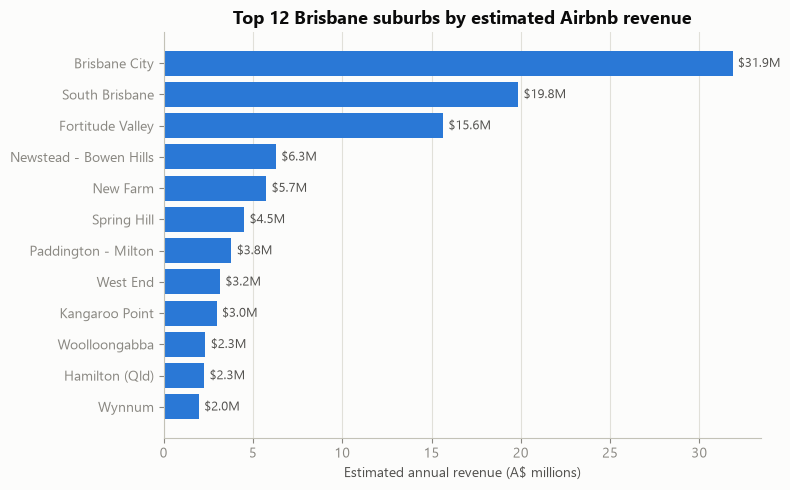

Brisbane City alone generates an estimated A\$31.9M/year — the top 3 inner-city suburbs shown make up 67% of the revenue in this top-12 list.


In [2]:
q1 = query('''
    SELECT
        n.neighbourhood_name,
        COUNT(*) AS total_listings,
        ROUND(SUM(l.estimated_revenue_l365d)) AS total_estimated_revenue_aud
    FROM listings l
    JOIN neighbourhoods n ON n.neighbourhood_id = l.neighbourhood_id
    GROUP BY n.neighbourhood_name
    ORDER BY total_estimated_revenue_aud DESC NULLS LAST
    LIMIT 12
''')

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = q1.sort_values('total_estimated_revenue_aud')
bars = ax.barh(plot_df['neighbourhood_name'], plot_df['total_estimated_revenue_aud'] / 1e6, color=BLUE)
ax.set_title('Top 12 Brisbane suburbs by estimated Airbnb revenue')
ax.set_xlabel('Estimated annual revenue (A$ millions)')
style_ax(ax)
for bar, val in zip(bars, plot_df['total_estimated_revenue_aud']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'\${val/1e6:.1f}M',
            va='center', fontsize=9, color=INK_SECONDARY)
savefig(fig, 'q1_revenue_by_suburb.png')

top3_share = q1['total_estimated_revenue_aud'].head(3).sum() / q1['total_estimated_revenue_aud'].sum()
print(f"{q1.iloc[0]['neighbourhood_name']} alone generates an estimated "
      f"A\${q1.iloc[0]['total_estimated_revenue_aud']/1e6:.1f}M/year — the top 3 inner-city "
      f"suburbs shown make up {top3_share:.0%} of the revenue in this top-12 list.")


## Q2. Price landscape: median nightly price by suburb and room type

The top 1% of prices (>= 99th percentile) is excluded — manual inspection found
a small number of implausible "deterrent" prices hosts set when they don't
actually want bookings (see `sql/03_business_analysis.sql` header note).


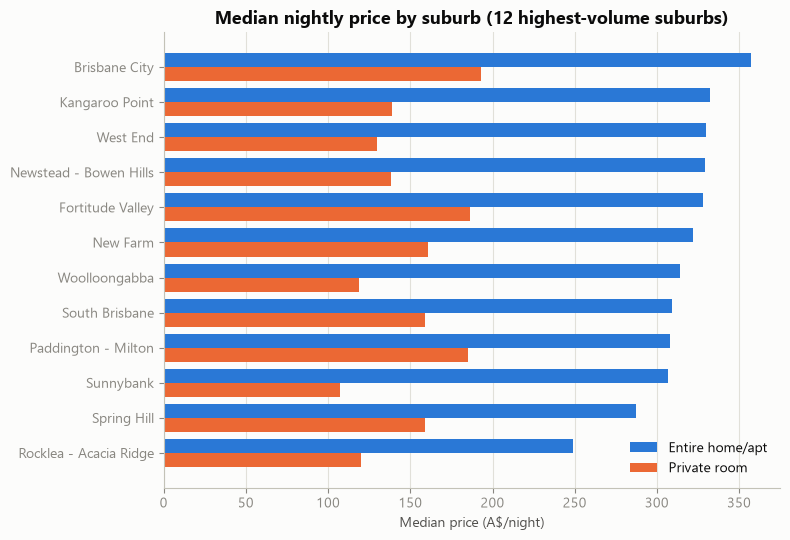

room_type               Entire home/apt  Private room
neighbourhood_name                                   
Rocklea - Acacia Ridge            249.0         120.0
Spring Hill                       287.0         159.0
Sunnybank                         307.0         107.0
Paddington - Milton               308.0         185.0
South Brisbane                    309.0         159.0
Woolloongabba                     314.0         119.0
New Farm                          322.0         161.0
Fortitude Valley                  328.0         186.0
Newstead - Bowen Hills            329.0         138.0
West End                          330.0         130.0
Kangaroo Point                    332.0         139.0
Brisbane City                     357.0         193.0


In [3]:
q2 = query('''
    WITH price_bounds AS (
        SELECT percentile_cont(0.99) WITHIN GROUP (ORDER BY price) AS p99
        FROM listings WHERE price IS NOT NULL
    ),
    ranked AS (
        SELECT n.neighbourhood_name, COUNT(*) AS n_listings
        FROM listings l JOIN neighbourhoods n ON n.neighbourhood_id = l.neighbourhood_id
        WHERE l.price IS NOT NULL
        GROUP BY n.neighbourhood_name
        ORDER BY n_listings DESC LIMIT 12
    )
    SELECT
        n.neighbourhood_name,
        l.room_type,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY l.price)::NUMERIC) AS median_price_aud
    FROM listings l
    JOIN neighbourhoods n ON n.neighbourhood_id = l.neighbourhood_id
    JOIN ranked r ON r.neighbourhood_name = n.neighbourhood_name
    CROSS JOIN price_bounds pb
    WHERE l.price IS NOT NULL AND l.price <= pb.p99
      AND l.room_type IN ('Entire home/apt', 'Private room')
    GROUP BY n.neighbourhood_name, l.room_type
''')

pivot = q2.pivot(index='neighbourhood_name', columns='room_type', values='median_price_aud')
pivot = pivot.loc[pivot['Entire home/apt'].sort_values().index]

fig, ax = plt.subplots(figsize=(8, 5.5))
y = range(len(pivot))
ax.barh([i + 0.2 for i in y], pivot['Entire home/apt'], height=0.4, color=BLUE, label='Entire home/apt')
ax.barh([i - 0.2 for i in y], pivot['Private room'], height=0.4, color=ORANGE, label='Private room')
ax.set_yticks(list(y))
ax.set_yticklabels(pivot.index)
ax.set_title('Median nightly price by suburb (12 highest-volume suburbs)')
ax.set_xlabel('Median price (A$/night)')
ax.legend(frameon=False, loc='lower right')
style_ax(ax)
savefig(fig, 'q2_price_by_suburb_roomtype.png')
print(pivot.round(0))


## Q3. Who earns it: single-listing hosts vs. multi-listing operators

Listing counts here are computed **from this dataset directly** (`COUNT(*)` per
`host_id`), not Airbnb's own `host_listings_count` field, which reflects a
host's activity across every city they operate in, not just Brisbane.


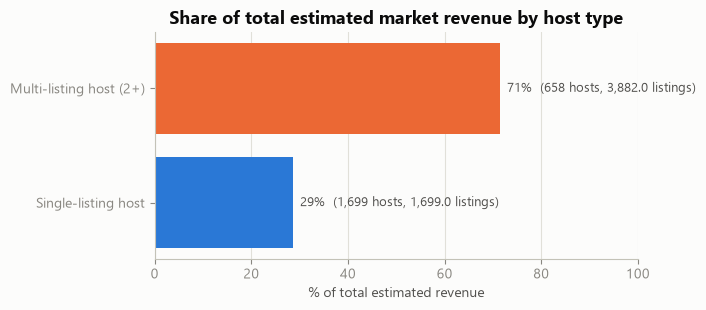

In [4]:
q3 = query('''
    WITH host_local_counts AS (
        SELECT host_id, COUNT(*) AS local_listing_count, SUM(estimated_revenue_l365d) AS host_revenue
        FROM listings WHERE estimated_revenue_l365d IS NOT NULL
        GROUP BY host_id
    )
    SELECT
        CASE WHEN local_listing_count = 1 THEN 'Single-listing host' ELSE 'Multi-listing host (2+)' END AS host_type,
        COUNT(*) AS n_hosts,
        SUM(local_listing_count) AS n_listings,
        ROUND(SUM(host_revenue)) AS total_revenue_aud
    FROM host_local_counts
    GROUP BY host_type
''')
q3['pct_of_revenue'] = q3['total_revenue_aud'] / q3['total_revenue_aud'].sum()

fig, ax = plt.subplots(figsize=(7, 3.2))
colors = [BLUE, ORANGE]
bars = ax.barh(q3['host_type'], q3['pct_of_revenue'] * 100, color=colors)
ax.set_title('Share of total estimated market revenue by host type')
ax.set_xlabel('% of total estimated revenue')
style_ax(ax, x_is_pct=False)
ax.set_xlim(0, 100)
for bar, row in zip(bars, q3.itertuples()):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{row.pct_of_revenue:.0%}  ({row.n_hosts:,} hosts, {row.n_listings:,} listings)',
            va='center', fontsize=9, color=INK_SECONDARY)
savefig(fig, 'q3_revenue_by_host_type.png')


## Q4. The superhost effect

Restricted to listings with 5+ reviews, so brand-new listings with no track
record don't distort the comparison.


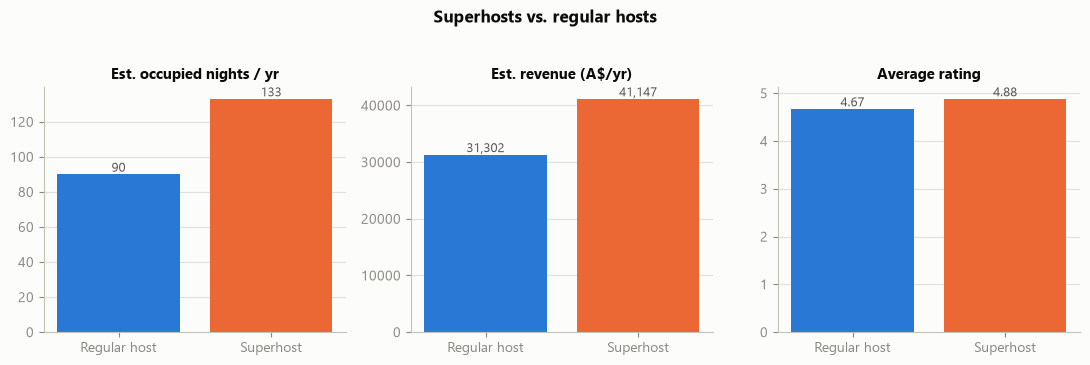

Superhosts earn an estimated 31% more per listing per year than regular hosts.


In [5]:
q4 = query('''
    SELECT
        CASE WHEN h.host_is_superhost THEN 'Superhost' ELSE 'Regular host' END AS host_group,
        ROUND(AVG(l.estimated_occupancy_l365d)) AS avg_occupied_nights,
        ROUND(AVG(l.estimated_revenue_l365d)) AS avg_revenue_aud,
        ROUND(AVG(l.review_scores_rating)::NUMERIC, 2) AS avg_rating
    FROM listings l JOIN hosts h ON h.host_id = l.host_id
    WHERE l.number_of_reviews >= 5
    GROUP BY host_group
''').set_index('host_group').loc[['Regular host', 'Superhost']]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
metrics = [('avg_occupied_nights', 'Est. occupied nights / yr'),
           ('avg_revenue_aud', 'Est. revenue (A$/yr)'),
           ('avg_rating', 'Average rating')]
for ax, (col, title) in zip(axes, metrics):
    ax.bar(q4.index, q4[col], color=[BLUE, ORANGE])
    ax.set_title(title, fontsize=11)
    style_ax(ax)
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', linewidth=0.8)
    for i, v in enumerate(q4[col]):
        ax.text(i, v, f'{v:,.2f}' if col == 'avg_rating' else f'{v:,.0f}',
                ha='center', va='bottom', fontsize=9, color=INK_SECONDARY)
fig.suptitle('Superhosts vs. regular hosts', fontweight='bold', y=1.03)
savefig(fig, 'q4_superhost_effect.png')

lift = (q4.loc['Superhost', 'avg_revenue_aud'] / q4.loc['Regular host', 'avg_revenue_aud'] - 1)
print(f'Superhosts earn an estimated {lift:.0%} more per listing per year than regular hosts.')


## Q5. Forward booking pace (next 12 months)

`calendar` is **forward-looking** (the 365 days following the 2026-07-14
scrape), and "unavailable" mixes real bookings with host-blocked dates — a
known Inside Airbnb limitation. Read this as a booking-pace signal, not a
historical occupancy trend.


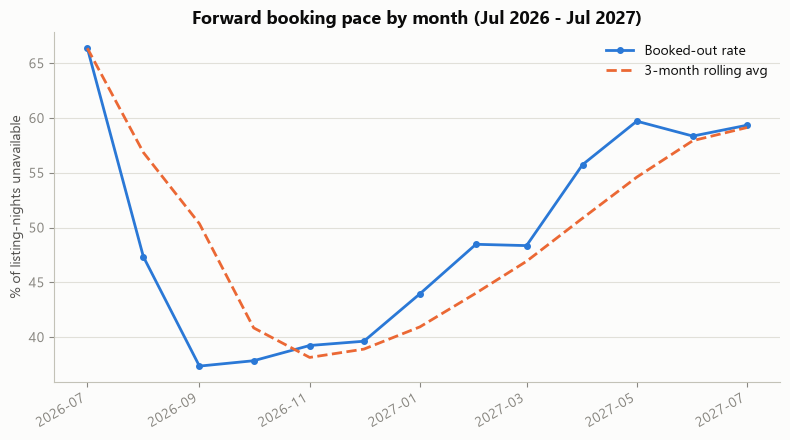

In [6]:
q5 = query('''
    WITH monthly AS (
        SELECT date_trunc('month', calendar_date)::date AS month,
               ROUND(100.0 * COUNT(*) FILTER (WHERE available = false) / COUNT(*), 2) AS booked_out_rate_pct
        FROM calendar GROUP BY 1
    )
    SELECT month, booked_out_rate_pct,
           ROUND(AVG(booked_out_rate_pct) OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2) AS rolling_3mo_avg
    FROM monthly ORDER BY month
''')
q5['month'] = pd.to_datetime(q5['month'])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q5['month'], q5['booked_out_rate_pct'], color=BLUE, marker='o', markersize=4, linewidth=2, label='Booked-out rate')
ax.plot(q5['month'], q5['rolling_3mo_avg'], color=ORANGE, linewidth=2, linestyle='--', label='3-month rolling avg')
ax.set_title('Forward booking pace by month (Jul 2026 - Jul 2027)')
ax.set_ylabel('% of listing-nights unavailable')
ax.legend(frameon=False)
style_ax(ax)
ax.grid(axis='y', linewidth=0.8)
ax.grid(axis='x', visible=False)
fig.autofmt_xdate()
savefig(fig, 'q5_booking_pace.png')


## Q6. Commercial-scale hosts and revenue concentration

Ranking by portfolio size (`RANK()`) and a running total of revenue share
(`SUM() OVER (ORDER BY ...)`) together show how concentrated the market is.


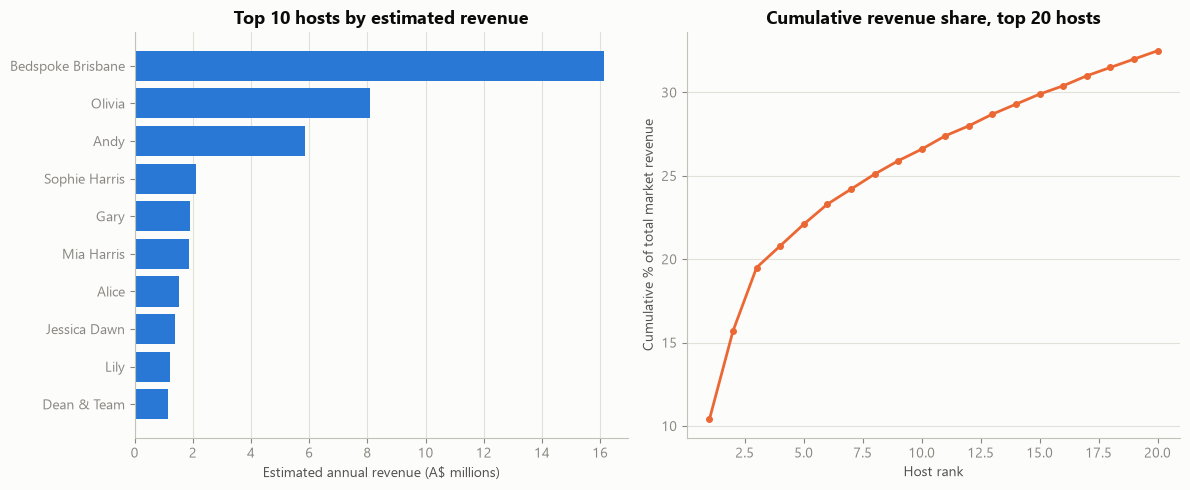

The single largest host, Bedspoke Brisbane, runs 286 listings and accounts for 10.4% of total market revenue on its own. The top 3 hosts combined reach 19.5%.


In [7]:
q6 = query('''
    WITH host_summary AS (
        SELECT h.host_id, h.host_name, COUNT(*) AS n_listings, SUM(l.estimated_revenue_l365d) AS total_revenue_aud
        FROM listings l JOIN hosts h ON h.host_id = l.host_id
        GROUP BY h.host_id, h.host_name
    )
    SELECT host_name, n_listings, total_revenue_aud,
           ROUND(100.0 * SUM(total_revenue_aud) OVER (ORDER BY total_revenue_aud DESC NULLS LAST ROWS UNBOUNDED PRECEDING)
                 / SUM(total_revenue_aud) OVER (), 1) AS cumulative_pct_of_market_revenue
    FROM host_summary ORDER BY total_revenue_aud DESC NULLS LAST LIMIT 20
''')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top10 = q6.head(10).sort_values('total_revenue_aud')
axes[0].barh(top10['host_name'], top10['total_revenue_aud'] / 1e6, color=BLUE)
axes[0].set_title('Top 10 hosts by estimated revenue')
axes[0].set_xlabel('Estimated annual revenue (A$ millions)')
style_ax(axes[0])

axes[1].plot(range(1, len(q6) + 1), q6['cumulative_pct_of_market_revenue'], color=ORANGE, marker='o', markersize=4, linewidth=2)
axes[1].set_title('Cumulative revenue share, top 20 hosts')
axes[1].set_xlabel('Host rank')
axes[1].set_ylabel('Cumulative % of total market revenue')
style_ax(axes[1])
axes[1].grid(axis='x', visible=False)
axes[1].grid(axis='y', linewidth=0.8)
savefig(fig, 'q6_host_concentration.png')

print(f"The single largest host, {q6.iloc[0]['host_name']}, runs {q6.iloc[0]['n_listings']} listings and "
      f"accounts for {q6.iloc[0]['cumulative_pct_of_market_revenue']}% of total market revenue on its own. "
      f"The top 3 hosts combined reach {q6.iloc[2]['cumulative_pct_of_market_revenue']}%.")


## Q7. Market growth: how many of today's listings are new?

`first_review` is used as a "went live" proxy (Airbnb no longer publishes
`host_since`/listing-creation date in this export). This counts listings that
are **still active today**, grouped by the year they started — it shows the
vintage mix of the current market, not total listings ever created (some
older listings will have since been delisted and aren't counted).


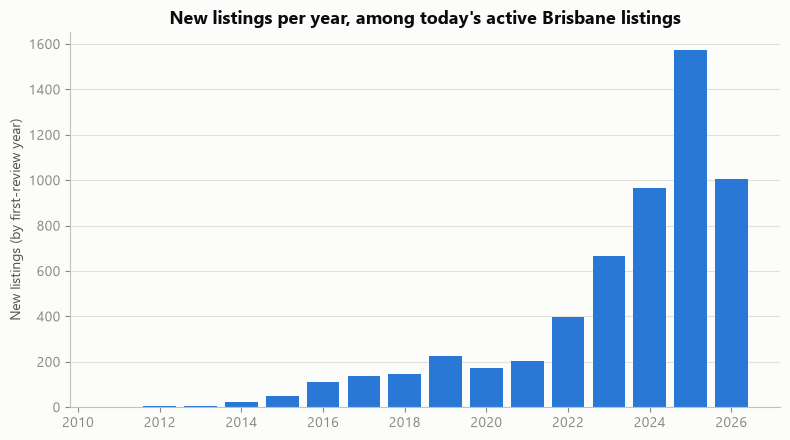

1,573 of today's active listings went live in 2025 alone — the biggest single-year cohort on record.


In [8]:
q7 = query('''
    WITH yearly AS (
        SELECT EXTRACT(YEAR FROM first_review)::INT AS year, COUNT(*) AS new_listings
        FROM listings WHERE first_review IS NOT NULL GROUP BY 1
    )
    SELECT year, new_listings, SUM(new_listings) OVER (ORDER BY year) AS cumulative_active_listings
    FROM yearly ORDER BY year
''')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(q7['year'], q7['new_listings'], color=BLUE)
ax.set_title("New listings per year, among today's active Brisbane listings")
ax.set_ylabel('New listings (by first-review year)')
style_ax(ax)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linewidth=0.8)
savefig(fig, 'q7_market_growth.png')

y2025 = int(q7.loc[q7['year'] == 2025, 'new_listings'].iloc[0])
print(f'{y2025:,} of today\'s active listings went live in 2025 alone — the biggest single-year cohort on record.')


## Q8. Demand momentum: where is review growth fastest?

Review volume is used as the standard Airbnb-market proxy for booking
activity. Suburbs with fewer than 20 reviews in the prior 12 months are
excluded so a handful of new reviews doesn't produce a meaningless %.


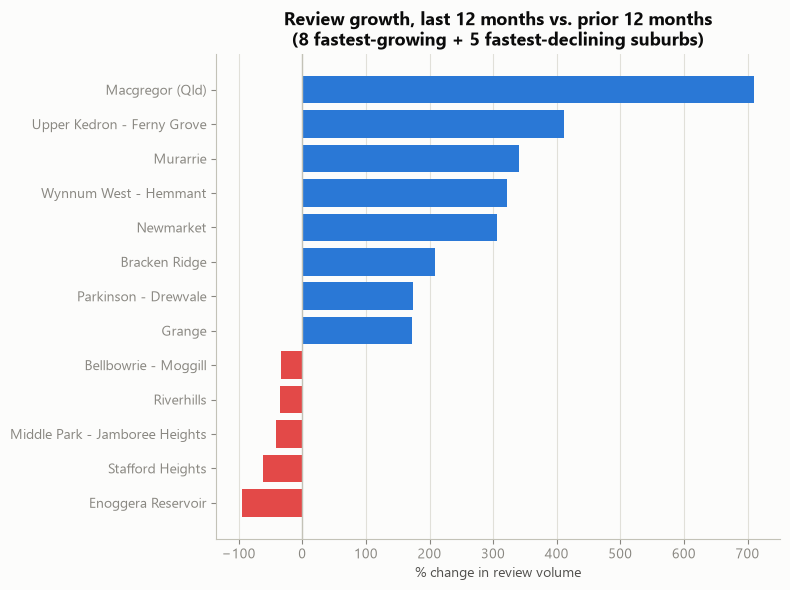

In [9]:
q8 = query('''
    WITH bounds AS (SELECT MAX(review_date) AS max_date FROM reviews),
    review_periods AS (
        SELECT l.neighbourhood_id,
               CASE WHEN r.review_date >= b.max_date - INTERVAL '12 months' THEN 'last_12mo'
                    WHEN r.review_date >= b.max_date - INTERVAL '24 months' THEN 'prior_12mo' END AS period
        FROM reviews r JOIN listings l ON l.listing_id = r.listing_id CROSS JOIN bounds b
    )
    SELECT n.neighbourhood_name,
           COUNT(*) FILTER (WHERE period='prior_12mo') AS reviews_prior_12mo,
           COUNT(*) FILTER (WHERE period='last_12mo') AS reviews_last_12mo,
           ROUND(100.0 * (COUNT(*) FILTER (WHERE period='last_12mo') - COUNT(*) FILTER (WHERE period='prior_12mo'))
                 / NULLIF(COUNT(*) FILTER (WHERE period='prior_12mo'), 0), 1) AS pct_change
    FROM review_periods rp JOIN neighbourhoods n ON n.neighbourhood_id = rp.neighbourhood_id
    WHERE period IS NOT NULL
    GROUP BY n.neighbourhood_name
    HAVING COUNT(*) FILTER (WHERE period='prior_12mo') >= 20
    ORDER BY pct_change DESC
''')

top_bottom = pd.concat([q8.head(8), q8.tail(5)]).sort_values('pct_change')
colors = [BLUE if v >= 0 else RED for v in top_bottom['pct_change']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_bottom['neighbourhood_name'], top_bottom['pct_change'], color=colors)
ax.axvline(0, color=BASELINE, linewidth=1)
ax.set_title('Review growth, last 12 months vs. prior 12 months\n(8 fastest-growing + 5 fastest-declining suburbs)')
ax.set_xlabel('% change in review volume')
style_ax(ax)
savefig(fig, 'q8_demand_momentum.png')


## Q9. Genuine tourism vs. mid/long-stay: minimum-night policy mix

A 30+ night minimum stay functions like a standard lease, not a short-term
rental — relevant to the housing-supply debate around how much of Brisbane's
Airbnb stock is really "short stay."


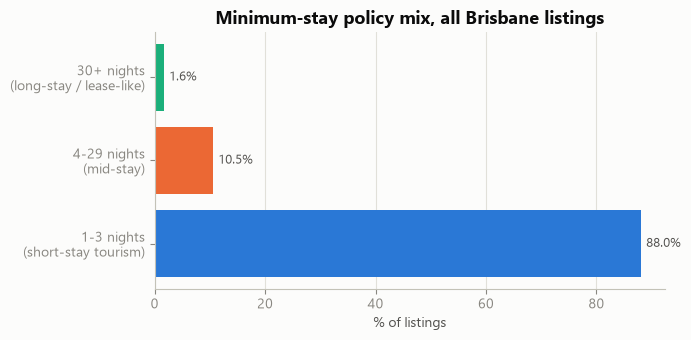

In [10]:
q9 = query('''
    SELECT CASE
             WHEN minimum_nights <= 3 THEN '1-3 nights\n(short-stay tourism)'
             WHEN minimum_nights BETWEEN 4 AND 29 THEN '4-29 nights\n(mid-stay)'
             ELSE '30+ nights\n(long-stay / lease-like)'
           END AS stay_policy,
           COUNT(*) AS n_listings,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_market
    FROM listings GROUP BY 1 ORDER BY 2 DESC
''')

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(q9['stay_policy'], q9['pct_of_market'], color=[BLUE, ORANGE, AQUA])
ax.set_title('Minimum-stay policy mix, all Brisbane listings')
ax.set_xlabel('% of listings')
style_ax(ax)
for bar, val in zip(bars, q9['pct_of_market']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9, color=INK_SECONDARY)
savefig(fig, 'q9_stay_policy_mix.png')


## Q10. Best value-for-money: top-rated listing per suburb, below the median price

Combines a CTE (suburb+room-type median price), a join, and `ROW_NUMBER()`
partitioned by suburb to pick one standout listing per area.


In [11]:
q10 = query('''
    WITH suburb_median AS (
        SELECT neighbourhood_id, room_type, PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price) AS median_price
        FROM listings WHERE price IS NOT NULL GROUP BY neighbourhood_id, room_type
    ),
    candidates AS (
        SELECT n.neighbourhood_name, l.name, l.room_type, l.price, l.review_scores_rating, l.number_of_reviews,
               ROW_NUMBER() OVER (PARTITION BY n.neighbourhood_name
                                   ORDER BY l.review_scores_rating DESC, l.number_of_reviews DESC) AS rn
        FROM listings l
        JOIN neighbourhoods n ON n.neighbourhood_id = l.neighbourhood_id
        JOIN suburb_median sm ON sm.neighbourhood_id = l.neighbourhood_id AND sm.room_type = l.room_type
        WHERE l.price < sm.median_price AND l.review_scores_rating >= 4.8 AND l.number_of_reviews >= 10
    )
    SELECT neighbourhood_name, name, room_type, price, review_scores_rating, number_of_reviews
    FROM candidates WHERE rn = 1
    ORDER BY review_scores_rating DESC, number_of_reviews DESC LIMIT 15
''')
q10


,neighbourhood_name,name,room_type,price,review_scores_rating,number_of_reviews
0,Karana Downs,Guest house,Entire home/apt,139.00,5.0,183
1,Brookfield - Kenmore Hills,Forest Retreat Studio for like-hearted nature ...,Entire home/apt,163.00,5.0,101
2,Bardon,Room with a garden view in Bardon,Private room,115.00,5.0,91
3,Fortitude Valley,Fortitude Valley Luxury Hosted Stay,Private room,185.50,5.0,79
4,Spring Hill,Entire two bedroom apartment at Spring Hill,Entire home/apt,255.80,5.0,61
5,New Farm,Quiet & Bright Art Deco Apartment by New Farm ...,Entire home/apt,296.00,5.0,52
6,East Brisbane,Apartment in East Brisbane,Entire home/apt,209.33,5.0,49
7,Mitchelton,The Poinciana Room,Private room,148.50,5.0,47
8,Greenslopes,New! Luxury 1 Bedroom Apartment,Entire home/apt,293.33,5.0,45
9,Nudgee - Banyo,Cosy retreat central to entertainment and airport,Entire home/apt,183.00,5.0,42
